2.1 理论计算题

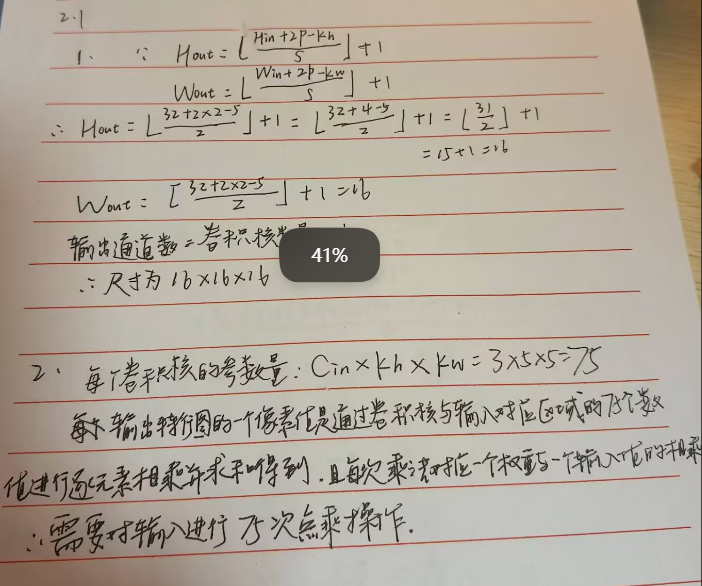

2.2 编程题

In [8]:
import numpy as np

def max_pool2d_manual(x, kernel_size, stride=1, padding=0):
    """
    x: (H, W) or (C, H, W) or (N, C, H, W)
    kernel_size: int or (kh, kw)
    stride: int or (sh, sw)
    padding: int or (ph, pw)
    """
    # 统一参数格式
    if isinstance(kernel_size, int):
        kh = kw = kernel_size
    else:
        kh, kw = kernel_size
    if isinstance(stride, int):
        sh = sw = stride
    else:
        sh, sw = stride
    if isinstance(padding, int):
        ph = pw = padding
    else:
        ph, pw = padding

    # 处理不同维度输入
    original_shape = x.shape
    if len(original_shape) == 2:
        x = x[None, None, ...]
    elif len(original_shape) == 3:
        x = x[None, ...]
    # 现在形状为 (N, C, H, W)
    N, C, H, W = x.shape

    # 填充
    x_pad = np.pad(x, ((0,0), (0,0), (ph, ph), (pw, pw)), mode='constant')

    # 计算输出尺寸
    H_out = (H + 2*ph - kh) // sh + 1
    W_out = (W + 2*pw - kw) // sw + 1

    output = np.zeros((N, C, H_out, W_out))

    for n in range(N):
        for c in range(C):
            for i in range(H_out):
                for j in range(W_out):
                    h_start = i * sh
                    h_end = h_start + kh
                    w_start = j * sw
                    w_end = w_start + kw
                    window = x_pad[n, c, h_start:h_end, w_start:w_end]
                    output[n, c, i, j] = np.max(window)

    # 恢复原形状
    if len(original_shape) == 2:
        return output[0, 0]
    elif len(original_shape) == 3:
        return output[0]
    return output

# 测试
if __name__ == "__main__":
    x = np.random.randn(1, 3, 32, 32)
    out = max_pool2d_manual(x, kernel_size=2, stride=2, padding=0)
    print("Output shape:", out.shape)  # (1,3,16,16)

Output shape: (1, 3, 16, 16)


3.1 理论计算题

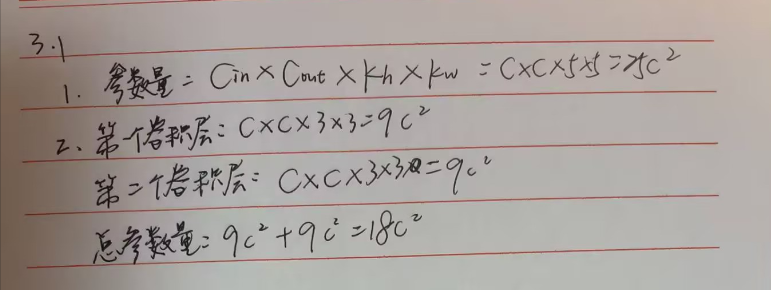

3.2 编程题

In [9]:
import torch
import torch.nn as nn

class NiNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.block(x)

# 测试
if __name__ == "__main__":
    block = NiNBlock(3, 96, kernel_size=3, stride=1, padding=1)
    x = torch.randn(1, 3, 224, 224)
    out = block(x)
    print("NiN block output shape:", out.shape)  # (1,96,224,224)

NiN block output shape: torch.Size([1, 96, 224, 224])


4.1 理论计算题

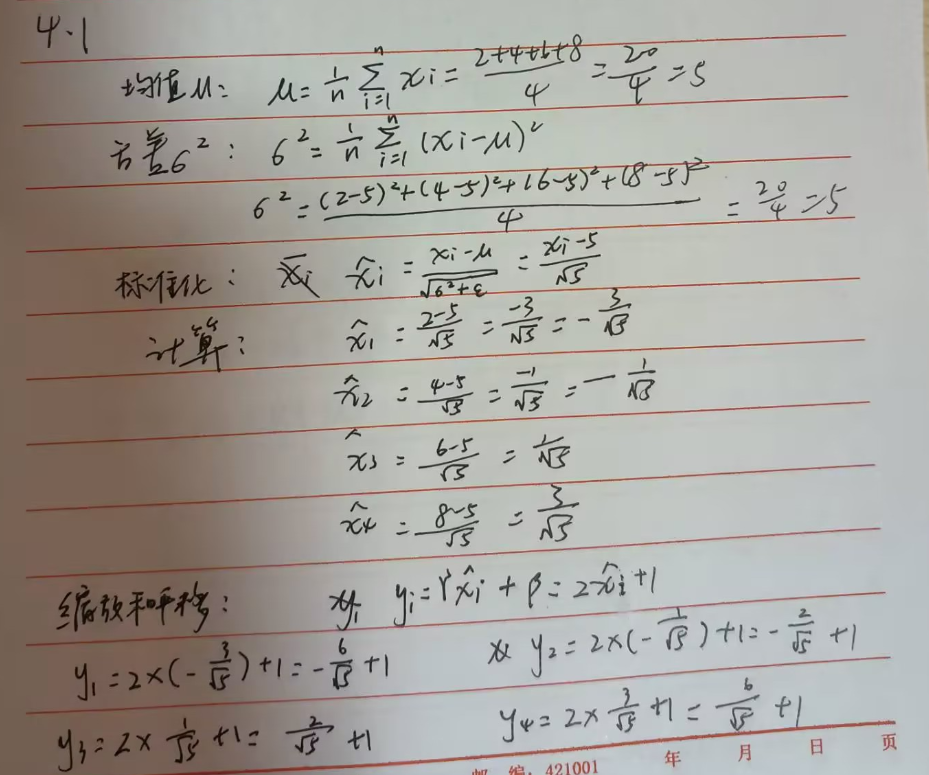

4.2 编程题

In [10]:
import torch
import torch.nn as nn

class Residual(nn.Module):
    def __init__(self, in_channels, out_channels, use_1x1conv=False, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

        if use_1x1conv:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        shortcut = self.shortcut(x)
        out += shortcut
        return self.relu(out)

# 测试
if __name__ == "__main__":
    block = Residual(3, 64, use_1x1conv=True, stride=2)
    x = torch.randn(1, 3, 32, 32)
    out = block(x)
    print("Residual block output shape:", out.shape)

Residual block output shape: torch.Size([1, 64, 16, 16])


5.1 理论计算题

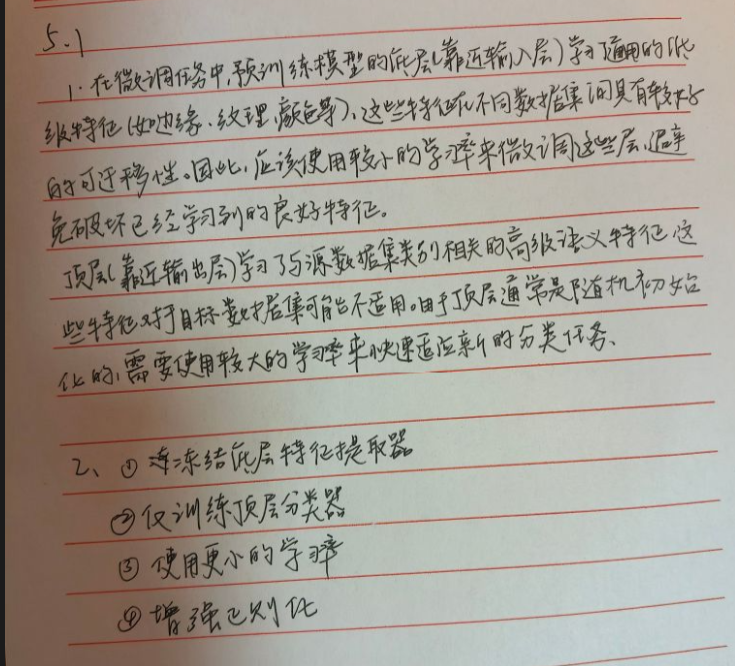

5.2 编程题

In [11]:
import torchvision.transforms as T

augmentation_pipeline = T.Compose([
    T.RandomResizedCrop(224, scale=(0.08, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    T.ToTensor()
])

# 测试
if __name__ == "__main__":
    from PIL import Image
    img = Image.new('RGB', (300, 300))
    out = augmentation_pipeline(img)
    print("Augmented image shape:", out.shape)  # (3, 224, 224)

Augmented image shape: torch.Size([3, 224, 224])


6.1 理论计算题

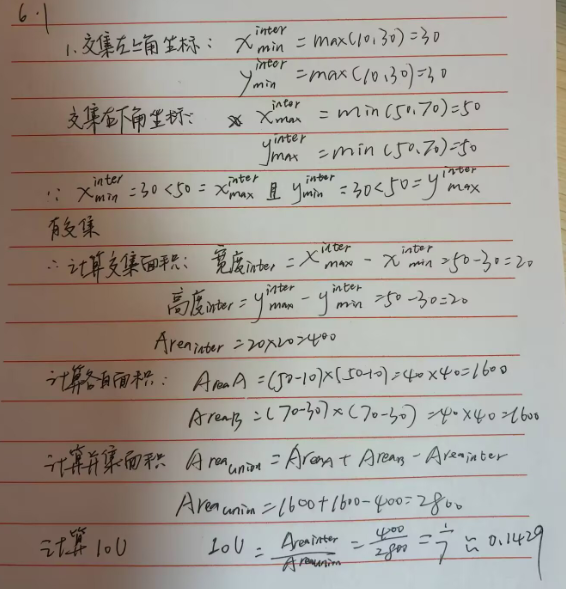

6.2 编程题

In [12]:
import torch
import torch.nn.functional as F

def label_smoothing_cross_entropy(logits, labels, epsilon=0.1):
    """
    logits: (N, C)
    labels: (N,) 类别索引
    epsilon: 平滑因子
    """
    num_classes = logits.size(-1)
    log_probs = F.log_softmax(logits, dim=-1)

    # 构造平滑标签
    smooth_labels = torch.full_like(log_probs, epsilon / (num_classes - 1))
    smooth_labels.scatter_(1, labels.unsqueeze(1), 1.0 - epsilon)

    # 计算损失
    loss = - (smooth_labels * log_probs).sum(dim=-1).mean()
    return loss

# 测试
if __name__ == "__main__":
    logits = torch.randn(4, 10)
    labels = torch.tensor([0, 1, 2, 3])
    loss = label_smoothing_cross_entropy(logits, labels, epsilon=0.1)
    print("Label smoothing CE loss:", loss.item())

Label smoothing CE loss: 2.887643814086914
